# FAPE, Law School Admissions Baseline Models
## Education/Legal Domain, Race Fairness Evaluation

**Dataset:** Law School Admissions, Wightman (1998), FairGround law_school_lequy  
**Records:** 18,692  
**Models:** Logistic Regression, Random Forest, Gradient Boosting  
**Sensitive:** racetxt (0=minority, 1=white), male (1=male, 0=female)  

**Key findings:**
- AUC=0.878 (GB), strong performance
- Race gap max_DP=0.329: minority applicants are predicted to pass far less often
- DIR=0.643, well below the 0.8 four-fifths convention
- Sex gap small under gradient boosting (DP -0.013 for women, +0.010 for men)
- 90.2% positive rate inflates F1, AUC is primary metric

In [1]:
%matplotlib inline
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve
from lawschool_loader import load_law_school
from baseline_lawschool import fairness_metrics

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
os.makedirs('../figures/baseline', exist_ok=True)
MODEL_COLORS = {'LogisticRegression':'steelblue','RandomForest':'coral','GradientBoosting':'#5cb85c'}
print('Imports complete')

Imports complete


In [2]:
result = load_law_school()
ds = result['law_school']
X = ds['X']; y = ds['y']
race = X['racetxt'].values; sex = X['male'].values

MODELS_NB = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

X_train,X_test,y_train,y_test,idx_tr,idx_te = train_test_split(
    X.values,y.values,np.arange(len(y)),test_size=0.2,random_state=42,stratify=y.values)
race_test=race[idx_te]; sex_test=sex[idx_te]
scaler=StandardScaler()
X_tr_sc=scaler.fit_transform(X_train); X_te_sc=scaler.transform(X_test)

all_results={}
for name,model in MODELS_NB.items():
    if name=='LogisticRegression':
        model.fit(X_tr_sc,y_train); y_pred=model.predict(X_te_sc); y_prob=model.predict_proba(X_te_sc)[:,1]
    else:
        model.fit(X_train,y_train); y_pred=model.predict(X_test); y_prob=model.predict_proba(X_test)[:,1]
    auc=roc_auc_score(y_test,y_prob); f1=f1_score(y_test,y_pred)
    fm_race=fairness_metrics(y_test,y_pred,race_test)
    fm_sex=fairness_metrics(y_test,y_pred,sex_test)
    dp_race=[abs(v['dp_diff']) for v in fm_race.values()]
    all_results[name]={'auc':auc,'f1':f1,'y_pred':y_pred,'y_prob':y_prob,'y_test':y_test,
                       'fairness_race':fm_race,'fairness_sex':fm_sex,
                       'max_dp_race':max(dp_race) if dp_race else 0}
    print(f'{name}: AUC={auc:.3f} F1={f1:.3f} max_DP={max(dp_race) if dp_race else 0:.3f}')
print('Done')

Loading Law School Admissions dataset via FairGround...
  OK: law_school_admissions: 18,692 rows | 11 features | sensitive: ['racetxt', 'male'] | positive rate: 0.902
LogisticRegression: AUC=0.872 F1=0.953 max_DP=0.308


RandomForest: AUC=0.854 F1=0.951 max_DP=0.300


GradientBoosting: AUC=0.878 F1=0.953 max_DP=0.329
Done


## 1. Model Comparison, AUC and F1

AUC=0.878 (GB). F1=0.953 inflated by 90.2% positive rate, AUC is primary metric.

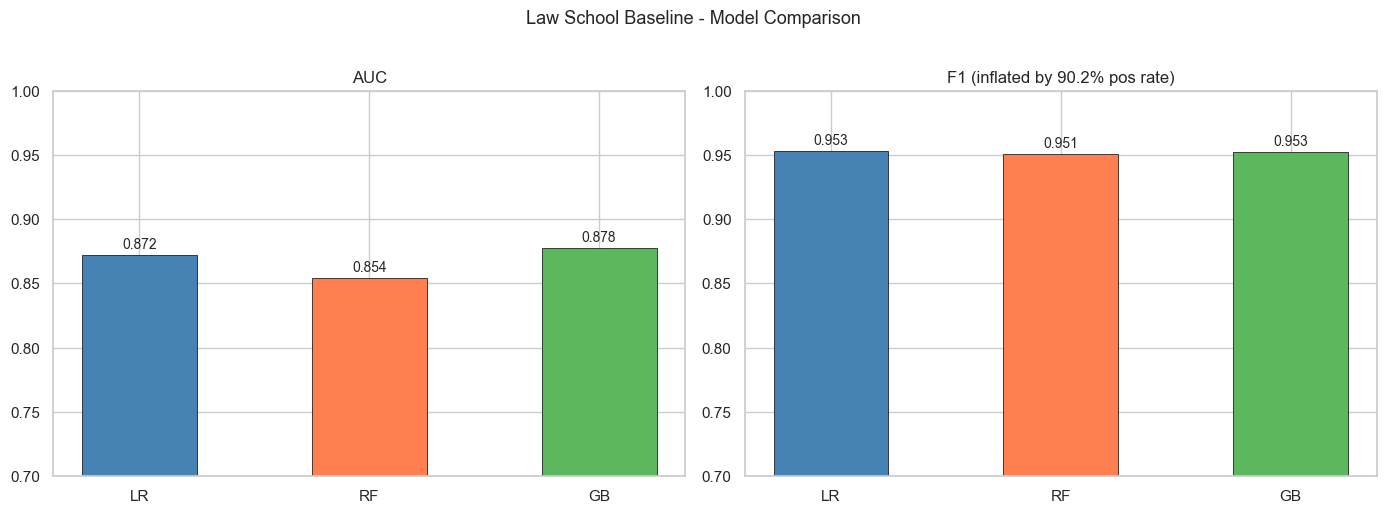

In [3]:
models=list(MODELS_NB.keys()); x=np.arange(len(models))
aucs=[all_results[n]['auc'] for n in models]
f1s=[all_results[n]['f1'] for n in models]

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
bars1=ax1.bar(x,aucs,width=0.5,color=[MODEL_COLORS[n] for n in models],edgecolor='black',linewidth=0.5)
bars2=ax2.bar(x,f1s,width=0.5,color=[MODEL_COLORS[n] for n in models],edgecolor='black',linewidth=0.5)
for bar,val in zip(bars1,aucs): ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,f'{val:.3f}',ha='center',fontsize=10)
for bar,val in zip(bars2,f1s): ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,f'{val:.3f}',ha='center',fontsize=10)
ax1.set_xticks(x); ax1.set_xticklabels(['LR','RF','GB']); ax1.set_title('AUC',fontsize=12); ax1.set_ylim(0.7,1.0)
ax2.set_xticks(x); ax2.set_xticklabels(['LR','RF','GB']); ax2.set_title('F1 (inflated by 90.2% pos rate)',fontsize=12); ax2.set_ylim(0.7,1.0)
plt.suptitle('Law School Baseline - Model Comparison',fontsize=13,y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/lawschool_model_comparison.png',dpi=150,bbox_inches='tight')
plt.show()

## 2. ROC Curves

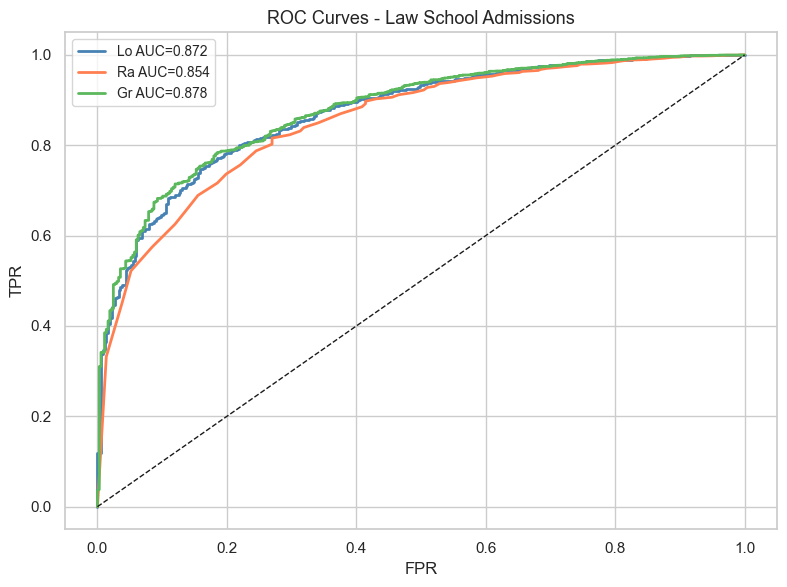

In [4]:
fig,ax=plt.subplots(figsize=(8,6))
for name,color in MODEL_COLORS.items():
    res=all_results[name]
    fpr_c,tpr_c,_=roc_curve(res['y_test'],res['y_prob'])
    ax.plot(fpr_c,tpr_c,label=f'{name[:2]} AUC={res["auc"]:.3f}',color=color,linewidth=2)
ax.plot([0,1],[0,1],'k--',linewidth=1)
ax.set_title('ROC Curves - Law School Admissions',fontsize=13)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../figures/baseline/lawschool_roc_curves.png',dpi=150,bbox_inches='tight')
plt.show()

## 3. Race FPR/TPR, Key Fairness Finding

Minority applicants (n=233) have a lower true positive rate under every model: 0.825 against 0.990 for White applicants under gradient boosting, 0.861 against 0.992 under logistic regression and 0.861 against 0.985 under random forest.

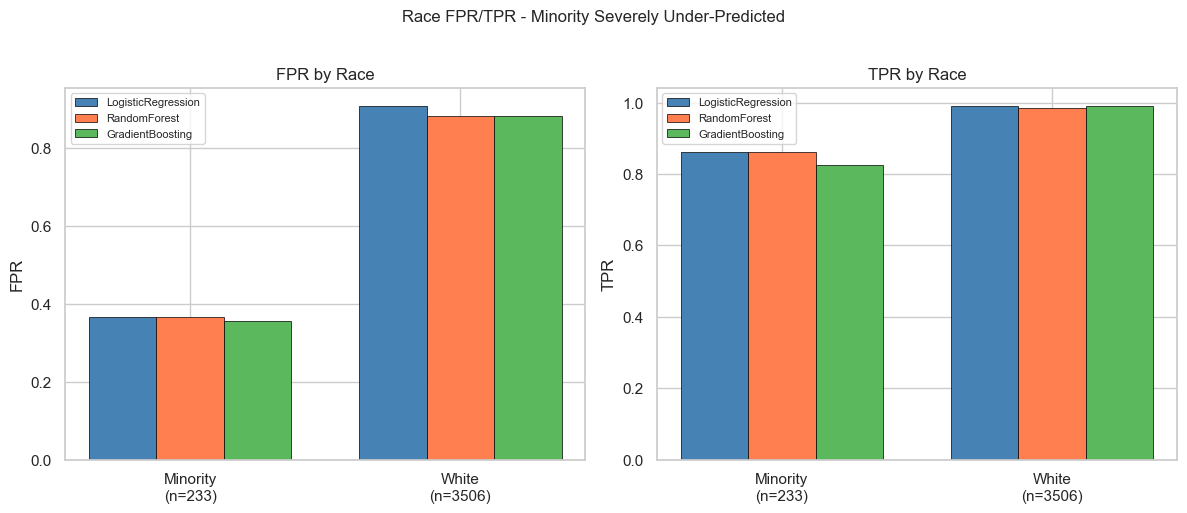

LogisticRegression: minority TPR 0.861 vs White TPR 0.992, a gap of 0.131
RandomForest: minority TPR 0.861 vs White TPR 0.985, a gap of 0.123
GradientBoosting: minority TPR 0.825 vs White TPR 0.990, a gap of 0.165


In [5]:
x=np.arange(2); width=0.25
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
for i,name in enumerate(MODELS_NB.keys()):
    fm=all_results[name]['fairness_race']
    fprs=[fm.get(g,{}).get('fpr',0) for g in [0,1]]
    tprs=[fm.get(g,{}).get('tpr',0) for g in [0,1]]
    ax1.bar(x+i*width,fprs,width,label=name,color=MODEL_COLORS[name],edgecolor='black',linewidth=0.5)
    ax2.bar(x+i*width,tprs,width,label=name,color=MODEL_COLORS[name],edgecolor='black',linewidth=0.5)
for ax,metric in [(ax1,'FPR'),(ax2,'TPR')]:
    ax.set_xticks(x+width); ax.set_xticklabels(['Minority\n(n=233)','White\n(n=3506)'])
    ax.set_title(f'{metric} by Race',fontsize=12); ax.set_ylabel(metric); ax.legend(fontsize=8)
plt.suptitle('Race FPR/TPR - Minority Severely Under-Predicted',fontsize=12,y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/lawschool_race_fairness.png',dpi=150,bbox_inches='tight')
plt.show()
for name in MODELS_NB:
    fm = all_results[name]['fairness_race']
    print(f"{name}: minority TPR {fm[0]['tpr']:.3f} vs White TPR {fm[1]['tpr']:.3f}, "
          f"a gap of {fm[1]['tpr'] - fm[0]['tpr']:.3f}")

## 4. Demographic Parity Difference by Race

Minority DP=-0.329 under gradient boosting (-0.308 for logistic regression, -0.300 for random forest).

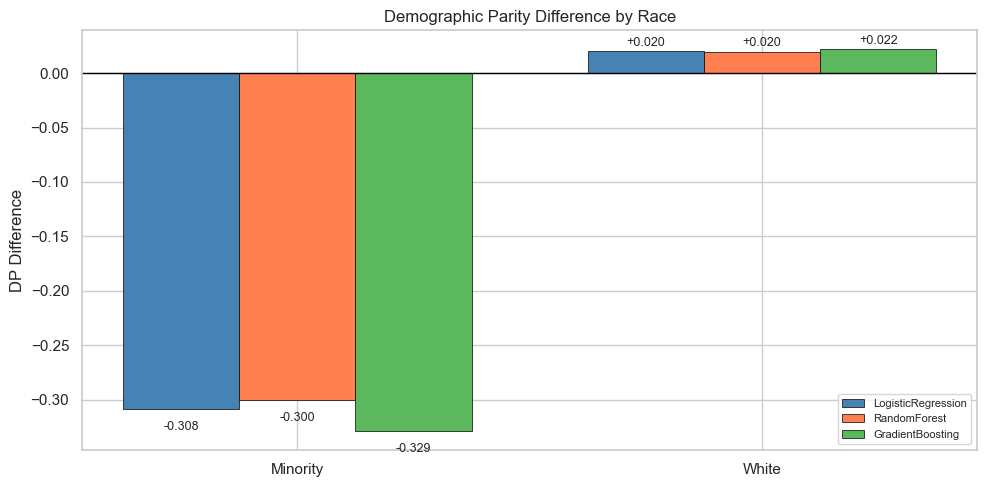

In [6]:
x=np.arange(2); width=0.25
fig,ax=plt.subplots(figsize=(10,5))
for i,name in enumerate(MODELS_NB.keys()):
    fm=all_results[name]['fairness_race']
    dps=[fm.get(g,{}).get('dp_diff',0) for g in [0,1]]
    bars=ax.bar(x+i*width,dps,width,label=name,color=MODEL_COLORS[name],edgecolor='black',linewidth=0.5)
    for bar,val in zip(bars,dps):
        ax.text(bar.get_x()+bar.get_width()/2,val+(0.005 if val>=0 else -0.02),f'{val:+.3f}',ha='center',fontsize=9)
ax.axhline(y=0,color='black',linewidth=1)
ax.set_xticks(x+width); ax.set_xticklabels(['Minority','White'])
ax.set_title('Demographic Parity Difference by Race',fontsize=12)
ax.set_ylabel('DP Difference'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../figures/baseline/lawschool_demographic_parity.png',dpi=150,bbox_inches='tight')
plt.show()

## 5. Sex Fairness, Minimal Gap

Under gradient boosting the sex DP difference is -0.013 for women and +0.010 for men, small next to the race gap (0.329).

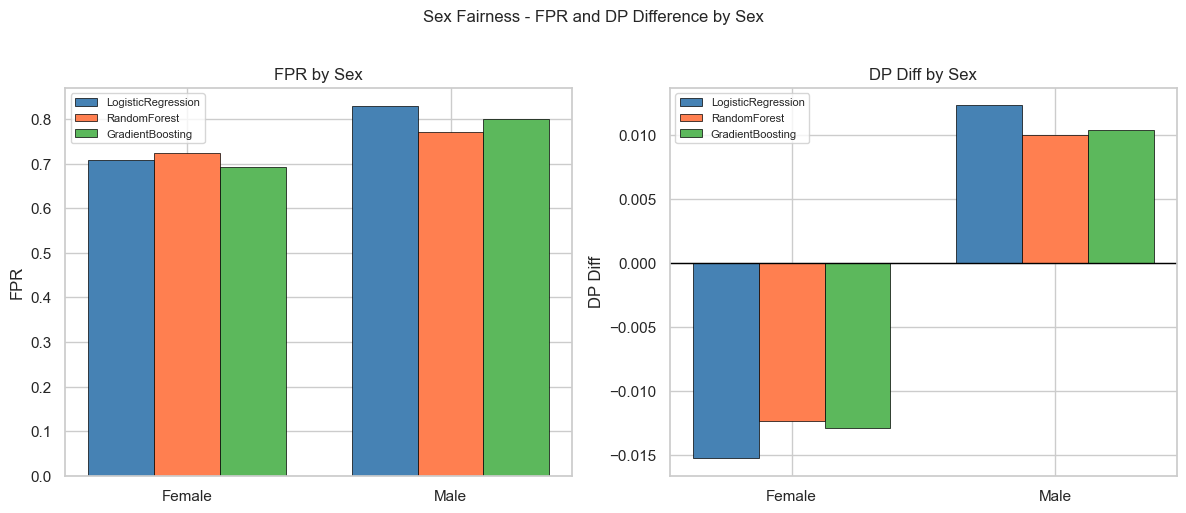

In [7]:
x=np.arange(2); width=0.25
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
for i,name in enumerate(MODELS_NB.keys()):
    fm=all_results[name]['fairness_sex']
    fprs=[fm.get(g,{}).get('fpr',0) for g in [0.0,1.0]]
    dps=[fm.get(g,{}).get('dp_diff',0) for g in [0.0,1.0]]
    ax1.bar(x+i*width,fprs,width,label=name,color=MODEL_COLORS[name],edgecolor='black',linewidth=0.5)
    ax2.bar(x+i*width,dps,width,label=name,color=MODEL_COLORS[name],edgecolor='black',linewidth=0.5)
for ax,metric in [(ax1,'FPR'),(ax2,'DP Diff')]:
    ax.set_xticks(x+width); ax.set_xticklabels(['Female','Male'])
    ax.set_title(f'{metric} by Sex',fontsize=12); ax.set_ylabel(metric); ax.legend(fontsize=8)
ax2.axhline(y=0,color='black',linewidth=1)
plt.suptitle('Sex Fairness - FPR and DP Difference by Sex',fontsize=12,y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/lawschool_sex_fairness.png',dpi=150,bbox_inches='tight')
plt.show()

## 6. Feature Importance, Gradient Boosting

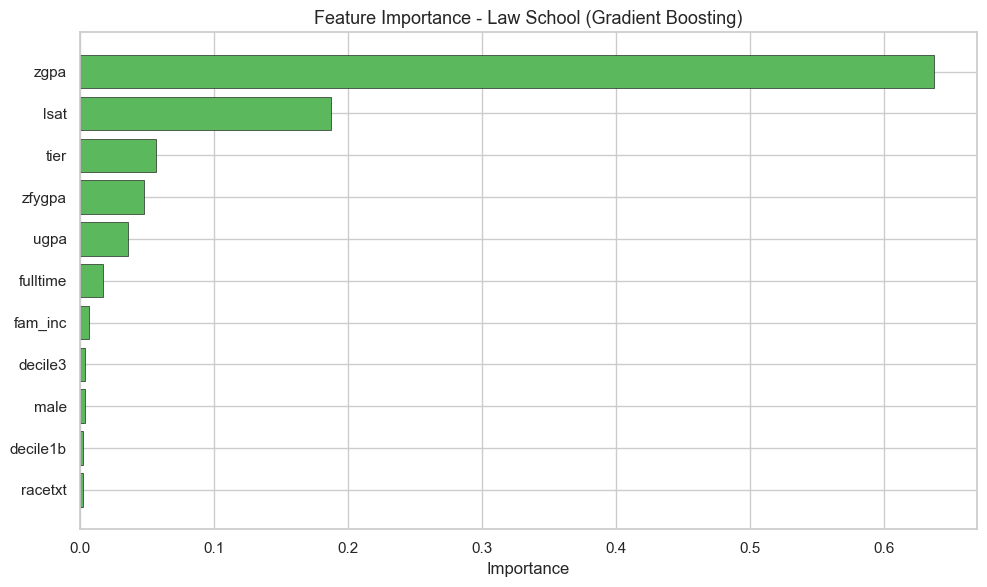

In [8]:
model=GradientBoostingClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
importances=model.feature_importances_; feat_names=list(ds['X'].columns)
top_idx=np.argsort(importances)[::-1]

fig,ax=plt.subplots(figsize=(10,6))
ax.barh([feat_names[i] for i in top_idx[::-1]],importances[top_idx[::-1]],
        color='#5cb85c',edgecolor='black',linewidth=0.4)
ax.set_title('Feature Importance - Law School (Gradient Boosting)',fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../figures/baseline/lawschool_feature_importance.png',dpi=150,bbox_inches='tight')
plt.show()

## 7. Confusion Matrix, Best Model (GB)

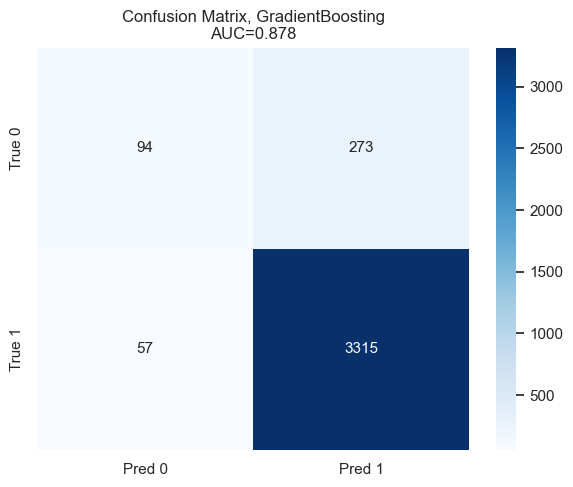

In [9]:
best_name=max(all_results.items(),key=lambda x: x[1]['auc'])[0]
res=all_results[best_name]
cm=confusion_matrix(res['y_test'],res['y_pred'])

fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,
            xticklabels=['Pred 0','Pred 1'],yticklabels=['True 0','True 1'])
ax.set_title(f'Confusion Matrix, {best_name}\nAUC={res["auc"]:.3f}',fontsize=12)
plt.tight_layout()
plt.savefig('../figures/baseline/lawschool_confusion_matrix.png',dpi=150,bbox_inches='tight')
plt.show()

## 8. Disparate Impact Ratio by Race

DIR=0.643 under gradient boosting, below the 0.8 four-fifths convention.

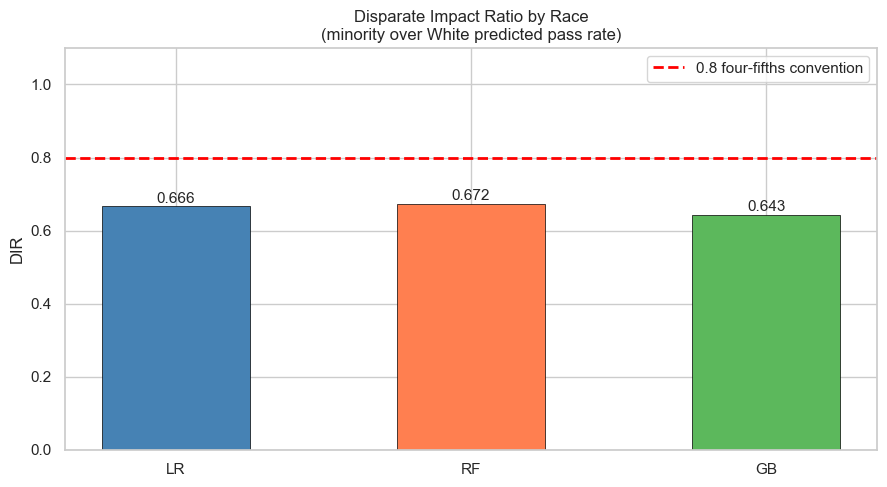

DIR by model: LogisticRegression 0.666, RandomForest 0.672, GradientBoosting 0.643


In [10]:
models=list(MODELS_NB.keys()); x=np.arange(len(models))
dirs=[]
for name in models:
    fm=all_results[name]['fairness_race']
    if 0 in fm and 1 in fm:
        dir_r=fm[0]['pos_rate']/fm[1]['pos_rate'] if fm[1]['pos_rate']>0 else 1
        dirs.append(dir_r)
    else:
        dirs.append(0)

fig,ax=plt.subplots(figsize=(9,5))
bars=ax.bar(x,dirs,width=0.5,color=[MODEL_COLORS[n] for n in models],edgecolor='black',linewidth=0.5)
for bar,val in zip(bars,dirs):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f'{val:.3f}',ha='center',fontsize=11)
ax.axhline(y=0.8,color='red',linestyle='--',linewidth=2,label='0.8 four-fifths convention')
ax.set_xticks(x); ax.set_xticklabels(['LR','RF','GB'])
ax.set_title('Disparate Impact Ratio by Race\n(minority over White predicted pass rate)',fontsize=12)
ax.set_ylabel('DIR'); ax.set_ylim(0,1.1); ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/lawschool_disparate_impact.png',dpi=150,bbox_inches='tight')
plt.show()
print('DIR by model: ' + ', '.join(f'{n} {v:.3f}' for n, v in zip(models, dirs)))

## 9. Intersectional Analysis, Race × Sex

Race matters far more than sex here. Gradient boosting predicts a pass for 60.5% to 64.5% of minority applicants against 97.7% to 98.5% of White applicants, and within each race group sex moves the rate by a few points (minority women 64.5%, minority men 60.5%).

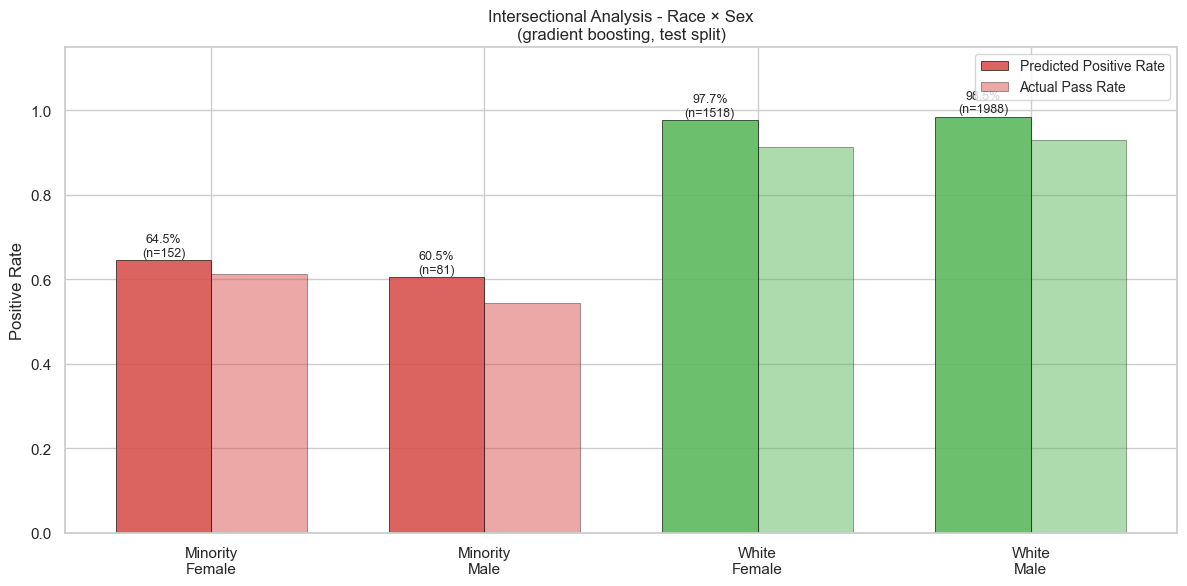

Minority Female: predicted 64.5%, true 61.2%, n=152
Minority Male: predicted 60.5%, true 54.3%, n=81
White Female: predicted 97.7%, true 91.2%, n=1518
White Male: predicted 98.5%, true 93.1%, n=1988


In [11]:
# Gradient boosting's predicted and true bar-passage rates by race and sex on the test split
gb_pred = all_results['GradientBoosting']['y_pred']
intersect_data = []
for r_code, r_name in [(0, 'Minority'), (1, 'White')]:
    for s_code, s_name in [(0, 'Female'), (1, 'Male')]:
        mask = (race_test == r_code) & (sex_test == s_code)
        intersect_data.append((f'{r_name}\n{s_name}', gb_pred[mask].mean(), y_test[mask].mean(), int(mask.sum())))

labels = [d[0] for d in intersect_data]
pred_rates = [d[1] for d in intersect_data]
true_rates = [d[2] for d in intersect_data]
ns = [d[3] for d in intersect_data]
colors = ['#d9534f','#d9534f','#5cb85c','#5cb85c']

x = np.arange(len(labels)); width = 0.35
fig, ax = plt.subplots(figsize=(12,6))
bars1 = ax.bar(x-width/2, pred_rates, width, label='Predicted Positive Rate',
               color=colors, edgecolor='black', linewidth=0.5, alpha=0.9)
bars2 = ax.bar(x+width/2, true_rates, width, label='Actual Pass Rate',
               color=colors, edgecolor='black', linewidth=0.5, alpha=0.5)
for bar, val, n in zip(bars1, pred_rates, ns):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.1%}\n(n={n})', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('Intersectional Analysis - Race × Sex\n'
             '(gradient boosting, test split)', fontsize=12)
ax.set_ylabel('Positive Rate'); ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../figures/baseline/lawschool_intersectional.png', dpi=150, bbox_inches='tight')
plt.show()
for label, pr, tr, n in intersect_data:
    print(f"{label.replace(chr(10), ' ')}: predicted {pr:.1%}, true {tr:.1%}, n={n}")

## 10. Key Findings

**AUC=0.878**, strong performance. F1=0.953 inflated by 90.2% positive rate.

**Race gap:** max_DP=0.329; minority applicants are predicted to pass far less often. Under gradient boosting, minority TPR is 0.825 against 0.990 for White applicants, a 16.5-point gap.

**DIR=0.643**, below the 0.8 four-fifths convention.

**Sex gap small:** DP -0.013 for women and +0.010 for men under gradient boosting.

**Minority group sparse:** 233 of the 3,739 test records (6.2%), so minority rates carry more sampling noise.

**Stage 2:** applies the demographic parity and equalized odds constraints by race.